In [ ]:
#run under conda deepchem enviroment
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, matthews_corrcoef
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

In [2]:
df_large_cov = pd.read_csv('final_dataset_for_classification_noisey.csv')
df_large_cov['Structure'] = df_large_cov['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_large_cov

,smiles,cov_label,crbn_chemspace,source,cov_crbn_label,Structure
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7d80>
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7df0>
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7e60>
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7ed0>
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7f40>
...,...,...,...,...,...,...
10517,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342dfc0>
10518,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e030>
10519,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e0a0>
10520,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e110>


In [3]:
#remove data when cov_label is 1 but crbn_chemspace is 0 (noise from general covalent database)
df_large_cov = df_large_cov[~((df_large_cov['cov_label'] == 1) & (df_large_cov['crbn_chemspace'] == 0))]
df_large_cov.reset_index(drop=True, inplace=True)
df_large_cov

,smiles,cov_label,crbn_chemspace,source,cov_crbn_label,Structure
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7d80>
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7df0>
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7e60>
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7ed0>
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7f40>
...,...,...,...,...,...,...
6582,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342dfc0>
6583,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e030>
6584,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e0a0>
6585,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e110>


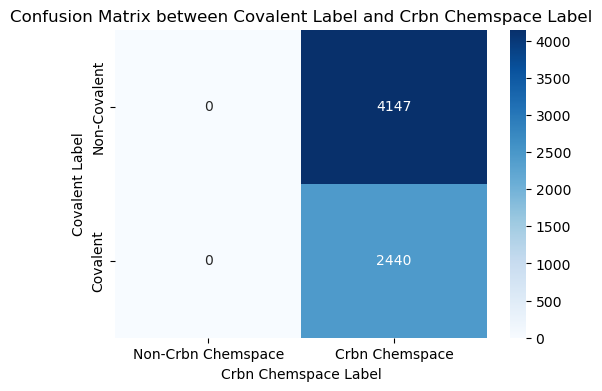

In [4]:
#check chemspace after enrichment
cm = confusion_matrix(df_large_cov['cov_label'], df_large_cov['crbn_chemspace'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Crbn Chemspace','Crbn Chemspace'], yticklabels=['Non-Covalent','Covalent'])
plt.xlabel('Crbn Chemspace Label')
plt.ylabel('Covalent Label')
plt.title('Confusion Matrix between Covalent Label and Crbn Chemspace Label')
plt.show()

In [5]:
df_large_cov[['smiles', 'cov_crbn_label']].to_csv('final_dataset_for_classification_only_crbn.csv', index=False)

In [6]:
# Analyze bit usage for different fingerprint sizes and radii
for b in [1024, 2048, 4096, 8192, 16384]:
    for r in range(2,4):
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=b)
        
        # Track bit usage counts
        bit_usage_counts = {}
        for x in df_large_cov['Structure']:
            mfp = fpg.GetFingerprint(x)
            for bit_idx in mfp.GetOnBits():
                bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        
        # Calculate statistics
        num_bits_used = len(bit_usage_counts)
        utilization = (num_bits_used / b) * 100
        usage_values = list(bit_usage_counts.values())
        
        print(f"Size {b}, Radius {r}: {num_bits_used} active bits ({utilization:.1f}% utilization)")
        print(f"  Bits used 1 time: {sum(1 for v in usage_values if v == 1)}")
        print(f"  Bits used 2-5 times: {sum(1 for v in usage_values if 2 <= v <= 5)}")
        print(f"  Bits used 6-10 times: {sum(1 for v in usage_values if 6 <= v <= 10)}")
        print(f"  Bits used >10 times: {sum(1 for v in usage_values if v > 10)}")
        print(f"  Average fragments per bit: {np.mean(usage_values):.1f}")
        print(f"  Max fragments for single bit: {max(usage_values)}")
        print()

Size 1024, Radius 2: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 2
  Bits used 6-10 times: 1
  Bits used >10 times: 1021
  Average fragments per bit: 333.6
  Max fragments for single bit: 6587

Size 1024, Radius 3: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 1024
  Average fragments per bit: 447.4
  Max fragments for single bit: 6587

Size 2048, Radius 2: 2045 active bits (99.9% utilization)
  Bits used 1 time: 2
  Bits used 2-5 times: 48
  Bits used 6-10 times: 195
  Bits used >10 times: 1800
  Average fragments per bit: 168.2
  Max fragments for single bit: 6587

Size 2048, Radius 3: 2048 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 2048
  Average fragments per bit: 227.3
  Max fragments for single bit: 6587

Size 4096, Radius 2: 4025 active bits (98.3% utilization)
  Bits u

In [7]:
# Re-create fingerprint generator with bit info tracking
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=8192)
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

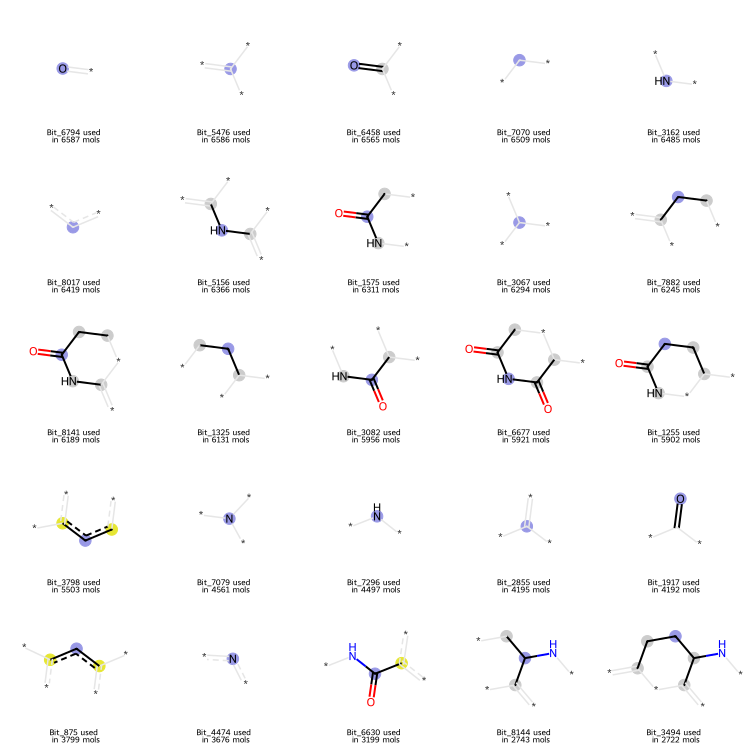

In [8]:
# Generate fingerprints to populate bit info map
bit_usage_counts = {}
all_with_label = []
for x in df_large_cov['Structure']:
    current_mfp = fpg.GetFingerprint(x, additionalOutput=ao)
    for bit_idx in current_mfp.GetOnBits():
        bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        fragment_tuple = (x, bit_idx, ao.GetBitInfoMap())
        all_with_label.append(fragment_tuple)

# draw most 25 unique bits sorted by usage
unique_bits = []
for mol, bit_idx, bit_info_map in all_with_label:
    if bit_idx not in [t[1] for t in unique_bits]:
        unique_bits.append((mol, bit_idx, bit_info_map))
unique_bits.sort(key=lambda x: bit_usage_counts[x[1]], reverse=True)
Draw.DrawMorganBits(unique_bits[:25], molsPerRow=5, legends=[f'Bit_{str(t[1])} used \n in {str(bit_usage_counts[t[1]])} mols' for t in unique_bits[:25]], subImgSize=(150,150))

In [9]:
# Create dataframe with fingerprint bits as columns
list_mfp = [fpg.GetFingerprint(x) for x in df_large_cov['Structure']]
bit_name = [f'Bit_{i}' for i in range(8192)]
bits = [list(l) for l in list_mfp]
df_mfp = pd.DataFrame(bits, columns=bit_name)
df_merged = pd.concat([df_large_cov, df_mfp], axis=1, join='inner')
df_merged.drop(columns=['Structure'])
df_merged

,smiles,cov_label,crbn_chemspace,source,cov_crbn_label,Structure,Bit_0,Bit_1,Bit_2,Bit_3,...,Bit_8182,Bit_8183,Bit_8184,Bit_8185,Bit_8186,Bit_8187,Bit_8188,Bit_8189,Bit_8190,Bit_8191
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7d80>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7df0>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7e60>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7ed0>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,open_database,0,<rdkit.Chem.rdchem.Mol object at 0x751bb93f7f40>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6582,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342dfc0>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6583,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e030>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6584,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e0a0>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6585,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1.0,1,cheminformatics_docking,1,<rdkit.Chem.rdchem.Mol object at 0x751ba342e110>,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X = df_merged.drop(columns=['smiles', 'cov_label', 'crbn_chemspace', 'source', 'cov_crbn_label', 'Structure'])
y = df_merged['cov_crbn_label']

In [11]:
# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, seed=42):
    """Return train/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    test_indices, train_indices = [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(test_indices)

train_idx, test_idx = scaffold_split_indices(df_merged['smiles'].tolist(), test_ratio=0.2, seed=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
len(X_train), len(X_test), len(y_train), len(y_test)

(5270, 1317, 5270, 1317)

In [ ]:
#save train and test set for later use
# X and y in same csv
# also include smiles for later use in interpretability and visualization
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df['smiles'] = df_merged.loc[train_idx, 'smiles'].values
test_df['smiles'] = df_merged.loc[test_idx, 'smiles'].values
train_df.to_csv('classic_ML_train_set.csv', index=False)
test_df.to_csv('classic_ML_test_set.csv', index=False)

In [13]:
# Hyperparameter grid for SVM
# Note: For high-dimensional fingerprints, 'linear' and 'rbf' are the most common kernels
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}
    
# Initialize Grid Search with SVC
# probability=True allows you to calculate ROC-AUC or soft-voting later
svc_model = SVC(probability=True)
grid_search = GridSearchCV(estimator=svc_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_svc = grid_search.best_estimator_
    
# Evaluation
y_pred = best_svc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Best Params: {grid_search.best_params_}")
print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")

Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Test MCC: 0.9859 | Test ACC: 0.9932


In [16]:
#save SVM model with best hyperparameters into pkl file for later use
svc_model = SVC(probability=True)
svc_model.set_params(**{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'})
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)
mcc_svc = matthews_corrcoef(y_test, y_pred_svc)
print(f"SVM with best hyperparameters - Test MCC: {mcc_svc:.4f} | Test ACC: {acc_svc:.4f}")
joblib.dump(svc_model, 'gridsearch_best_svc_model.pkl')

SVM with best hyperparameters - Test MCC: 0.9859 | Test ACC: 0.9932


['gridsearch_best_svc_model.pkl']

In [14]:
# Hyperparameter grid for RandomForestClassifier (slightly optimized for bit-vectors)
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'] # Better for high-dimensional chemical data
}
    
# Initialize Grid Search
rf_clf = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_rf_clf = grid_search.best_estimator_
    
# Evaluation
y_pred = best_rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
matt = matthews_corrcoef(y_test, y_pred)
print(f"Best Params: {grid_search.best_params_}")
print(f"Test MCC: {matt:.4f} | Test ACC: {acc:.4f}")

Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
Test MCC: 0.9843 | Test ACC: 0.9924


In [17]:
#save RF model with best hyperparameters into pkl file for later use
rf_model = RandomForestClassifier()
rf_model.set_params(**{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500})
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
print(f"Random Forest with best hyperparameters - Test MCC: {mcc_rf:.4f} | Test ACC: {acc_rf:.4f}")
joblib.dump(rf_model, 'gridsearch_best_rfc_model.pkl')

Random Forest with best hyperparameters - Test MCC: 0.9828 | Test ACC: 0.9916


['gridsearch_best_rfc_model.pkl']

In [ ]:
# Hyperparameter grid for XGBoost optimized for high-dimensional fingerprints
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6],           # Shallower trees prevent overfitting bit-vectors
    'n_estimators': [200, 500],
    'subsample': [0.8],
    'colsample_bytree': [0.7, 0.9], # Randomly select bits for each tree
    'gamma': [0, 0.1]
}

# pos_weight calculation to handle class imbalance
pos_weight = sum(y_train == 0) / sum(y_train == 1)

# Initialize XGBoost Grid Search
xgb_model = XGBClassifier(
objective='binary:logistic',
scale_pos_weight=pos_weight,
eval_metric='logloss'
)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
    
# Evaluation
y_pred = best_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)  
print(f"Best Params: {grid_search.best_params_}")
print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")


Best Params: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Test MCC: 0.9875 | Test ACC: 0.9939


In [23]:
#save xgboost model with best hyperparameters into pkl file for later use
xgb_model = XGBClassifier(
objective='binary:logistic',
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1),
eval_metric='logloss'
)
xgb_model.set_params(**{'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8})
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
print(f"XGBoost with best hyperparameters - Test MCC: {mcc_xgb:.4f} | Test ACC: {acc_xgb:.4f}")
joblib.dump(xgb_model, 'gridsearch_best_xgb_model.pkl')

XGBoost with best hyperparameters - Test MCC: 0.9875 | Test ACC: 0.9939


['gridsearch_best_xgb_model.pkl']

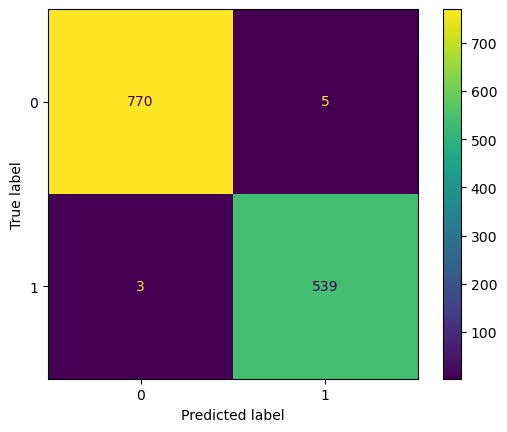

In [26]:
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.show()
plt.close()

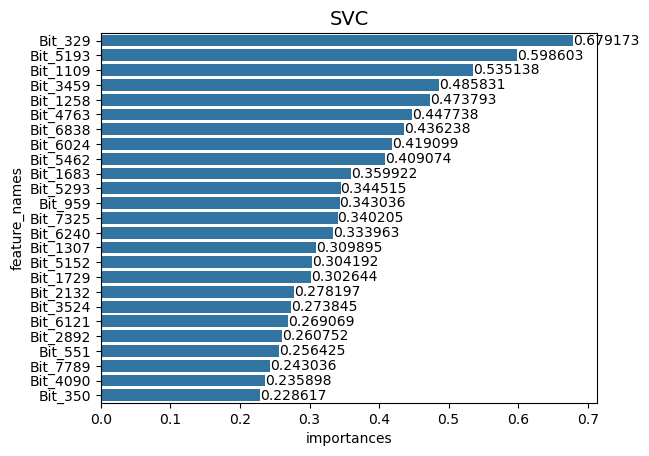

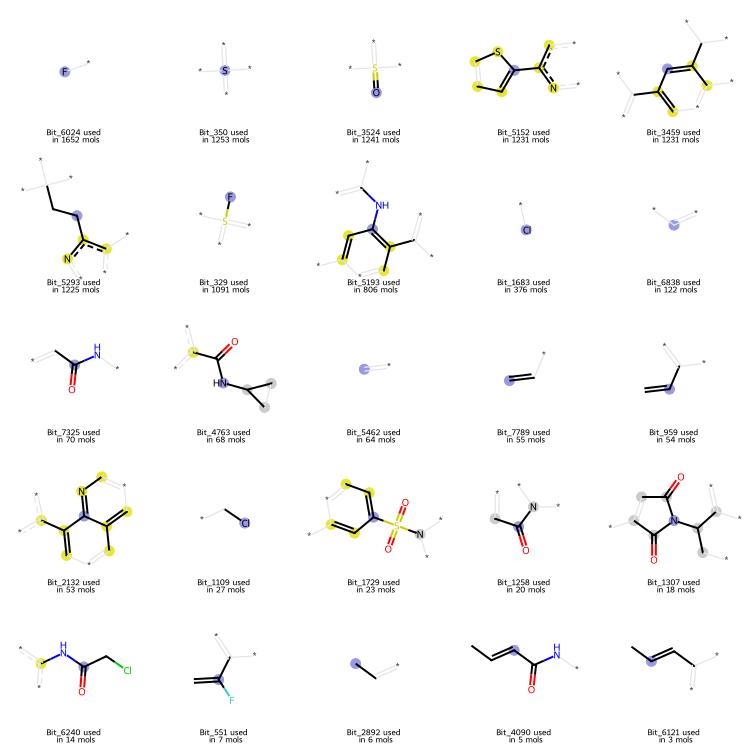

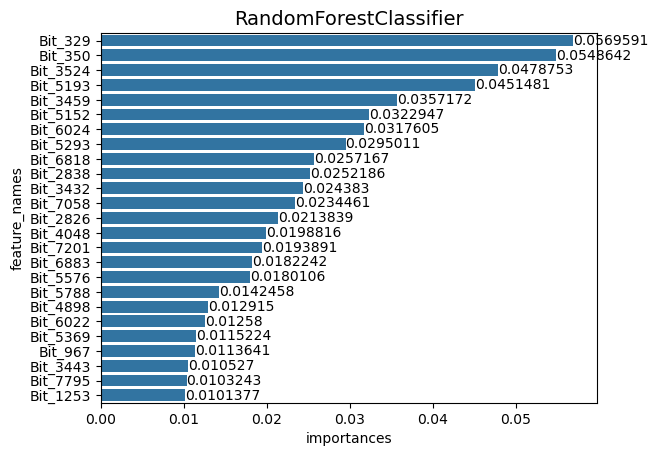

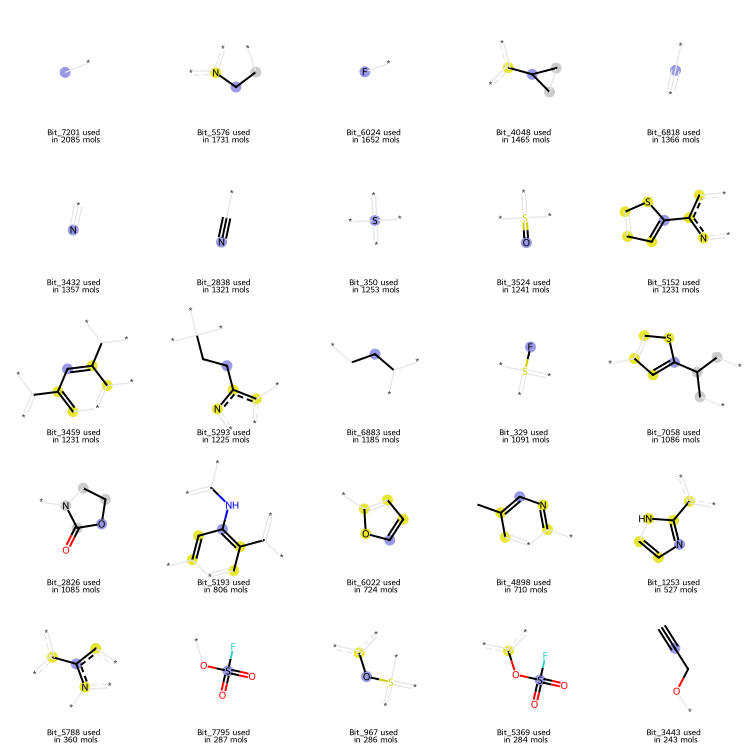

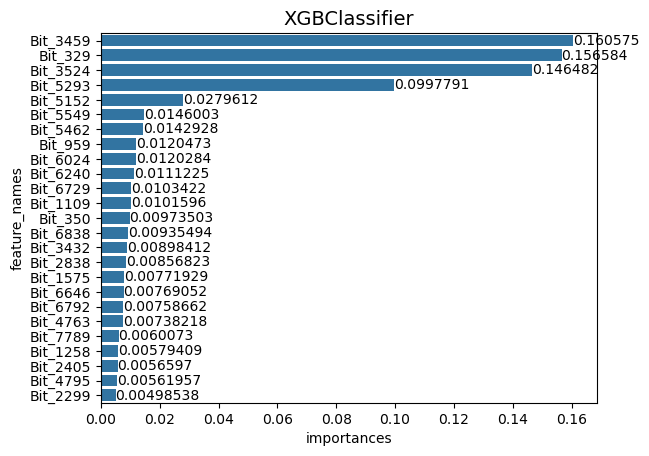

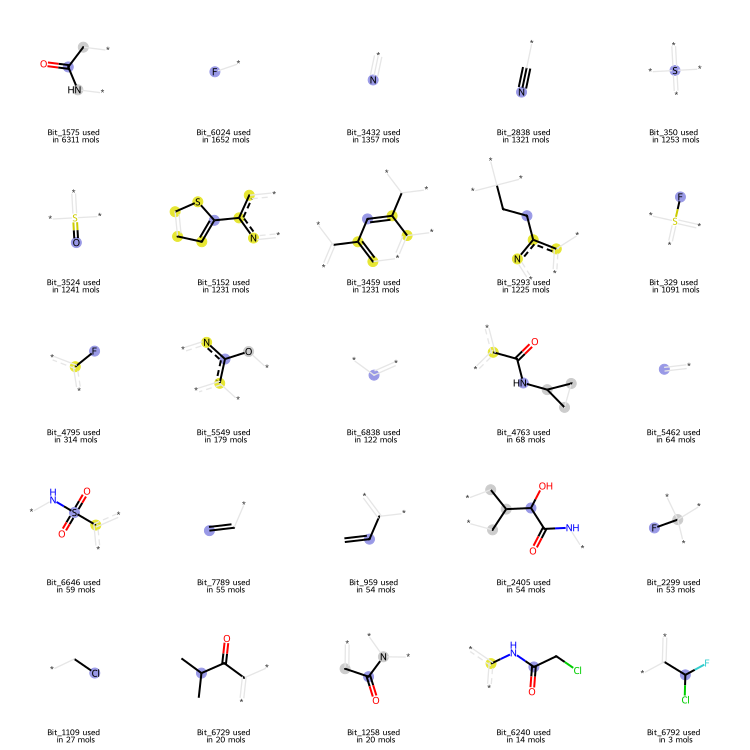

In [ ]:
def plot_top_features(model, unique_bits, top_num=25):    
    try:
        importances_df = pd.DataFrame({"feature_names" : model.feature_names_in_, 
                                    "importances" : model.feature_importances_})
    except:
        importances_df = pd.DataFrame({"feature_names" : model.feature_names_in_, 
                                    "importances" : model.coef_[0]})
    importances_df = importances_df.sort_values(by='importances', ascending=False).head(top_num)
    g = sns.barplot(y=importances_df["feature_names"], 
                    x=importances_df["importances"])
    g.set_title(model.__class__.__name__, fontsize=14)
    for value in g.containers:
        g.bar_label(value)
    plt.show()
    plt.close()
    #
    top_bits = [int(i.split('_')[-1]) for i in importances_df["feature_names"].tolist()]
    found_bits = [item for item in unique_bits if item[1] in top_bits]
    display(Draw.DrawMorganBits(found_bits, molsPerRow=5, legends=[f'Bit_{str(t[1])} used \n in {str(bit_usage_counts[t[1]])} mols' for t in found_bits], subImgSize=(150,150)))

plot_top_features(svc_model, unique_bits)
print("\n")
plot_top_features(rf_model, unique_bits)
print("\n")
plot_top_features(xgb_model, unique_bits)

In [ ]:
'''
gen_set_1_1 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach1.csv", index_col=False)["SMILES"].tolist()
gen_set_1_2 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach2.csv", index_col=False)["SMILES"].tolist()
gen_set_1 = gen_set_1_1 + gen_set_1_2
gen_set_1 = list(set(gen_set_1))
#
gen_set_2 = pd.read_csv("../genAI/reinvent4_test/cleaned_fresh_imide_molecules_top200_QED.csv", index_col=False)["SMILES"].tolist()
gen_set_2 = list(set(gen_set_2))
gen_set_combined = list(set(gen_set_1 + gen_set_2))
#
cov_dock_set = pd.read_csv("../covalent_docking_VS/covalent_docking_unique_2D_precursors_QED_filtered_above_049.csv", index_col=False)["SMILES"].tolist()
cov_dock_set = list(set(cov_dock_set))

#gen_set_combined label 0, cov_dock_set label 1, generate fingerprints, label and predict using best_svc, best_rf_clf, best_xgb
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=8192)

def generate_fingerprint_df(smiles_list):
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    fps = [fpg.GetFingerprint(mol) for mol in mols]
    bit_name = [f'Bit_{i}' for i in range(8192)]
    bits = [list(fp) for fp in fps]
    df_fp = pd.DataFrame(bits, columns=bit_name)
    return df_fp

X_gen_combined = generate_fingerprint_df(gen_set_combined)
y_gen_combined = np.zeros(len(gen_set_combined), dtype=int)
X_cov_dock = generate_fingerprint_df(cov_dock_set)
y_cov_dock = np.ones(len(cov_dock_set), dtype=int)

X_test_combined = pd.concat([X_gen_combined, X_cov_dock], ignore_index=True)
y_test_combined = np.concatenate([y_gen_combined, y_cov_dock])

y_pred_svc = best_svc.predict(X_test_combined)
acc_svc = accuracy_score(y_test_combined, y_pred_svc)
mcc_svc = matthews_corrcoef(y_test_combined, y_pred_svc)
print(f"SVC - Combined Test MCC: {mcc_svc:.4f} | Combined Test ACC: {acc_svc:.4f}")

y_pred_rf = best_rf_clf.predict(X_test_combined)
acc_rf = accuracy_score(y_test_combined, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test_combined, y_pred_rf)
print(f"Random Forest - Combined Test MCC: {mcc_rf:.4f} | Combined Test ACC: {acc_rf:.4f}")

y_pred_xgb = best_xgb.predict(X_test_combined)
acc_xgb = accuracy_score(y_test_combined, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test_combined, y_pred_xgb)
print(f"XGBoost - Combined Test MCC: {mcc_xgb:.4f} | Combined Test ACC: {acc_xgb:.4f}")
'''

In [ ]:
'''
#further tuning hyperparameters of XGBoost using Optuna based on Bayesian optimization
import optuna

def objective(trial):
    # 1. Define the search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1.0),
    }
    # 2. Initialize model with suggested params
    model = XGBClassifier(**param, random_state=42, eval_metric='logloss')
    
    # 3. Use all data to get a score (using MCC as our metric)
    score = cross_val_score(model, X, y, cv=5, scoring='matthews_corrcoef').mean()
    
    return score

# 4. Create a "study" and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
print(f"Best Params: {study.best_params}")

#test best XGBoost from Optuna on combined gen set
best_xgb_optuna = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb_optuna.fit(X, y)
y_pred_optuna = best_xgb_optuna.predict(X_test_combined)
acc_optuna = accuracy_score(y_test_combined, y_pred_optuna)
mcc_optuna = matthews_corrcoef(y_test_combined, y_pred_optuna)
print(f"Optuna-tuned XGBoost - Combined Test MCC: {mcc_optuna:.4f} | Combined Test ACC: {acc_optuna:.4f}")
'''

[I 2026-02-04 21:13:22,767] A new study created in memory with name: no-name-5b153e94-c699-49e9-aae2-90de20862175
[I 2026-02-04 21:16:19,471] Trial 0 finished with value: 0.936555550231914 and parameters: {'n_estimators': 226, 'max_depth': 8, 'learning_rate': 0.08738431849061976, 'subsample': 0.6434154837761564, 'colsample_bytree': 0.6212479713092047, 'gamma': 0.360299317003801}. Best is trial 0 with value: 0.936555550231914.
[I 2026-02-04 21:20:30,981] Trial 1 finished with value: 0.932820787104073 and parameters: {'n_estimators': 675, 'max_depth': 9, 'learning_rate': 0.054909968836766646, 'subsample': 0.8569448325809528, 'colsample_bytree': 0.9114684866854552, 'gamma': 0.8571490069519411}. Best is trial 0 with value: 0.936555550231914.
[I 2026-02-04 21:28:38,154] Trial 2 finished with value: 0.9362487859911436 and parameters: {'n_estimators': 417, 'max_depth': 10, 'learning_rate': 0.015399085551568995, 'subsample': 0.9191322537214991, 'colsample_bytree': 0.7318923611496289, 'gamma': 

Best Params: {'n_estimators': 509, 'max_depth': 3, 'learning_rate': 0.01487213596227653, 'subsample': 0.7817578623130783, 'colsample_bytree': 0.6164440249231762, 'gamma': 0.28194285190603147}
Optuna-tuned XGBoost - Combined Test MCC: 1.0000 | Combined Test ACC: 1.0000


In [ ]:
'''
#save XGBoost model with best hyperparameters from Optuna into pkl file for later use
optuna_xgb_model = XGBClassifier()
optuna_xgb_model.set_params(**{'n_estimators': 509, 'max_depth': 3, 'learning_rate': 0.01487213596227653, 'subsample': 0.7817578623130783, 'colsample_bytree': 0.6164440249231762, 'gamma': 0.28194285190603147}, random_state=42, eval_metric='logloss')
optuna_xgb_model.fit(X_train, y_train)
y_pred_optuna = optuna_xgb_model.predict(X_test)
acc_optuna = accuracy_score(y_test, y_pred_optuna)
mcc_optuna = matthews_corrcoef(y_test, y_pred_optuna)
print(f"Optuna-tuned XGBoost - Test MCC: {mcc_optuna:.4f} | Test ACC: {acc_optuna:.4f}")
#joblib.dump(optuna_xgb_model, 'optuna_tuned_xgb_model.pkl')
'''

Optuna-tuned XGBoost - Test MCC: 0.9796 | Test ACC: 0.9901
